# X-ray diseases classifier

This notebook demonstrates an image classification approach for analyzing chest X-ray images. The project uses the NIH Chest X-ray dataset and focuses on exploring a proof-of-concept method for detecting thoracic findings from medical imaging data.

Rabi Arbi, 2026

![banner](https://d1qpnt4t1p05jk.cloudfront.net/wp-content/uploads/2025/10/27082644/image-2544-1024x683.jpeg)

In [1]:
import collections, lightning, pandas as pd, platform, os, torch, torchvision, warnings

from torch.utils.data import Dataset, DataLoader
from lightning import LightningDataModule, LightningModule, Trainer
from torchvision import transforms
from torchmetrics.classification import MultilabelAccuracy, MultilabelPrecision, MultilabelRecall
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

import matplotlib.pyplot as plt

lightning.seed_everything(42)
torch.set_float32_matmul_precision("high")

data_path = "data"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

trainer_kwargs = {
    "accelerator": "gpu" if use_cuda else "cpu",
    "devices": 1,
}

if use_cuda:
    trainer_kwargs["precision"] = "16-mixed"

print(
    "Versions: python", platform.python_version(),
    "| torch", torch.__version__,
    "| torchvision", torchvision.__version__,
    "| lightning", lightning.__version__,
)
print("CUDA available:", use_cuda)
print("Active device:", device)
print("GPU:", torch.cuda.get_device_name(0) if use_cuda else "N/A")
print("Trainer kwargs:", trainer_kwargs)

W0326 22:55:13.957000 28332 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Seed set to 42


Versions: python 3.14.0 | torch 2.11.0+cu128 | torchvision 0.26.0+cu128 | lightning 2.6.1
CUDA available: True
Active device: cuda
GPU: NVIDIA GeForce RTX 5080
Trainer kwargs: {'accelerator': 'gpu', 'devices': 1, 'precision': '16-mixed'}


### explanation

- `collections` → counts labels and checks class balance  
- `lightning` → organizes training structure  
- `pandas` → reads and processes the dataset CSV  
- `platform` → shows Python/version info  
- `os` → handles file paths  
- `torch` → core deep learning library  
- `torchvision` → image utilities and transforms  
- `warnings` → controls warning messages  

- `Dataset` → builds a custom NIH dataset class  
- `DataLoader` → loads images in batches  

- `LightningDataModule` → manages data loading and splits  
- `LightningModule` → defines model, loss, and training steps  
- `Trainer` → runs training and validation  

- `transforms` → preprocesses X-ray images  
- `MultilabelAccuracy` → evaluates multi-label predictions  
- `MultilabelPrecision` → checks how many positive predictions are correct  
- `MultilabelRecall` → checks how many real positives are found  

- `CSVLogger` → saves training results  
- `EarlyStopping` → stops training when improvement stalls  
- `matplotlib.pyplot` → plots images and training curves  

- `seed_everything(42)` → makes runs reproducible  
- `set_float32_matmul_precision("high")` → improves GPU computation performance  
- `data_path = "data"` → sets dataset folder  
- `print(...)` → shows library versions

------------------------------------------------------------------------------------

# Loading a pre-trained model

In [2]:
import torch.nn as nn
import torchvision

num_classes = 14

pretrained_model = torchvision.models.resnet50(weights="DEFAULT")
pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, num_classes)

criterion = nn.BCEWithLogitsLoss()

## What each part does:

- `resnet50(weights="DEFAULT")` → loads pretrained ResNet50
- `nn.Linear(...)` → replaces the last layer
- `num_classes` = 14 → one output per chest finding
- `BCEWithLogitsLoss()` → correct loss for multi-label prediction

### Why the last layer was replaced

The old last layer was built for a different task.

This pretrained `ResNet50` came from ImageNet, so its final layer was made to predict **1000 ImageNet classes** such as dogs, cars, chairs, and other everyday objects.

This project is different:
- **input** = chest X-ray image  
- **output** = 14 thoracic findings  

So the original last layer does not match this target.

Inside the model:
- the early and middle layers learn general visual features  
- the last layer maps those features to the final class outputs  

That last mapping is task-specific.

The last layer was replaced because:
- the ImageNet output size is wrong  
- this project needs **14 outputs**  
- the new classes are completely different  
- this is how transfer learning adapts a pretrained model to a new task  

Simple example:

**Before**
- model sees an image  
- final layer predicts one of **1000 ImageNet classes**  

**After**
- model sees a chest X-ray  
- final layer predicts the 14 chest findings, such as **Atelectasis, Effusion, Mass, Pneumonia**, and others.

------------------------------------------------------------------------------------------------------

## Clean The Data


### No Finding Analysis

We will measure how many images are labeled **No Finding**. These samples may add less value for disease classification, so we review their proportion before deciding whether to keep or remove them.

CSV used: Data_Entry_2017.csv
Total images: 112120
Images with No Finding: 60361
No Finding ratio: 53.84%


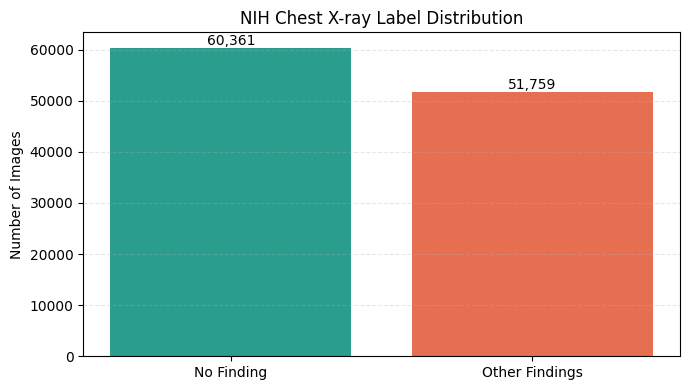

In [5]:
from pathlib import Path

# Locate NIH metadata CSV from common project layouts.
candidate_csv_paths = [
    Path(data_path) / "Data_Entry_2017.csv",
    Path("Data_Entry_2017.csv"),
    Path("archive") / "Data_Entry_2017.csv",
]

csv_path = next((p for p in candidate_csv_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find Data_Entry_2017.csv. Checked: "
        + ", ".join(str(p) for p in candidate_csv_paths)
    )

df = pd.read_csv(csv_path)

if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the metadata CSV.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
no_finding_count = int(no_finding_mask.sum())
total_images = len(df)
other_findings_count = total_images - no_finding_count

print(f"CSV used: {csv_path}")
print(f"Total images: {total_images}")
print(f"Images with No Finding: {no_finding_count}")
print(f"No Finding ratio: {no_finding_count / total_images:.2%}")

# Quick class-balance chart.
labels = ["No Finding", "Other Findings"]
counts = [no_finding_count, other_findings_count]
colors = ["#2a9d8f", "#e76f51"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=colors)
plt.title("NIH Chest X-ray Label Distribution")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Why It Can Be Better to Remove Some No Finding Images:
In this task, removing a portion of **No Finding** images can improve learning because the model then sees more disease-positive examples, reducing class imbalance and helping it focus on patterns related to thoracic abnormalities.

In [8]:
# Prints only the number of images after removal.
if "total_after" in globals():
    print(total_after)
elif "df_clean" in globals():
    print(len(df_clean))
else:
    raise NameError("Run the removal cell first to compute the post-removal image count.")

51759


Total images before: 112120
No Finding images removed: 60361
Total images after removal: 51759


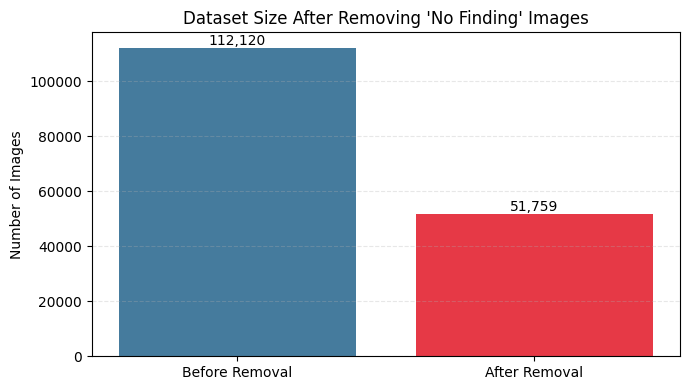

In [7]:
# Remove all rows labeled 'No Finding'.
if "Finding Labels" not in df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

no_finding_mask = df["Finding Labels"].fillna("").str.strip().eq("No Finding")
df_clean = df.loc[~no_finding_mask].copy()

total_before = len(df)
total_after = len(df_clean)
removed_count = total_before - total_after

print(f"Total images before: {total_before}")
print(f"No Finding images removed: {removed_count}")
print(f"Total images after removal: {total_after}")

# Final chart: dataset size before vs after removing No Finding rows.
labels = ["Before Removal", "After Removal"]
counts = [total_before, total_after]
colors = ["#457b9d", "#e63946"]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, counts, color=colors)
plt.title("Dataset Size After Removing 'No Finding' Images")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

Also some images in the dataset contain multiple disease labels, which can confuse the model because it is unclear which disease is the correct target. To improve model clarity and performance, these images will be removed. Only images with a single, clear disease label will be used, ensuring that each input corresponds to one specific prediction.


In [9]:
# Count images that have more than one disease label (excluding 'No Finding').
if "Finding Labels" not in df_clean.columns:
    raise KeyError("Column 'Finding Labels' was not found in df_clean.")

label_count = (
    df_clean["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

multi_disease_count = int((label_count > 1).sum())
print(multi_disease_count)

20796


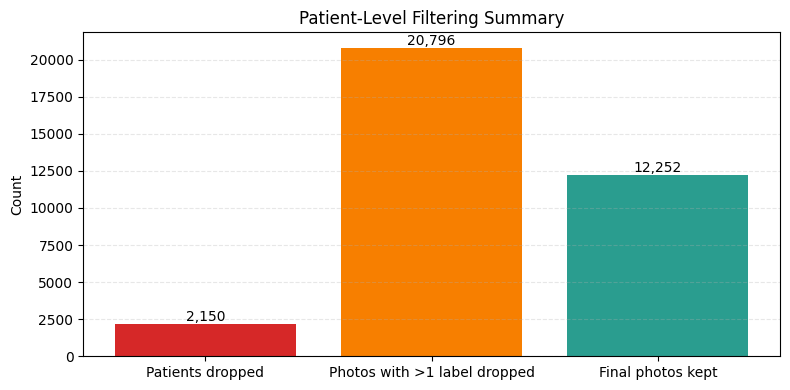

Patients dropped: 2150
Photos with >1 label dropped: 20796
Final photos kept (1 per patient): 12252


In [12]:
# Keep only one single-label image per patient and drop the rest.
base_df = df_clean.copy() if "df_clean" in globals() else df.copy()

if "Finding Labels" not in base_df.columns:
    raise KeyError("Column 'Finding Labels' was not found in the dataframe.")

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in base_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column was not found in the dataframe.")

label_count_base = (
    base_df["Finding Labels"]
    .fillna("")
    .apply(lambda x: len([lbl for lbl in x.split("|") if lbl.strip()]))
)

single_label_df = base_df.loc[label_count_base == 1].copy()

if "Image Index" in single_label_df.columns:
    single_label_df = single_label_df.sort_values([patient_col, "Image Index"])
else:
    single_label_df = single_label_df.sort_values([patient_col])

df_one_image_per_patient = single_label_df.drop_duplicates(subset=patient_col, keep="first").copy()

patients_before = int(base_df[patient_col].nunique())
patients_after = int(df_one_image_per_patient[patient_col].nunique())
patients_dropped = patients_before - patients_after

multi_label_photos_dropped = int((label_count_base > 1).sum())
final_photos_kept = int(len(df_one_image_per_patient))

labels = ["Patients dropped", "Photos with >1 label dropped", "Final photos kept"]
values = [patients_dropped, multi_label_photos_dropped, final_photos_kept]
colors = ["#d62828", "#f77f00", "#2a9d8f"]

plt.figure(figsize=(8, 4))
bars = plt.bar(labels, values, color=colors)
plt.title("Patient-Level Filtering Summary")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:,}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print(f"Patients dropped: {patients_dropped}")
print(f"Photos with >1 label dropped: {multi_label_photos_dropped}")
print(f"Final photos kept (1 per patient): {final_photos_kept}")

In [ ]:
# Randomly show 10 patients with one image ID and its label.
sample_df = df_one_image_per_patient.copy()

patient_col_candidates = ["Patient ID", "PatientID", "patient_id"]
patient_col = next((c for c in patient_col_candidates if c in sample_df.columns), None)
if patient_col is None:
    raise KeyError("Patient ID column not found.")

image_col_candidates = ["Image Index", "ImageID", "image_id"]
image_col = next((c for c in image_col_candidates if c in sample_df.columns), None)
if image_col is None:
    raise KeyError("Image ID column not found.")

if "Finding Labels" not in sample_df.columns:
    raise KeyError("'Finding Labels' column not found.")

total_images_kept = len(sample_df)
n = min(10, total_images_kept)
random_10 = sample_df.sample(n=n).loc[:, [patient_col, image_col, "Finding Labels"]]
random_10 = random_10.reset_index(drop=True)

print(f"Total images after all filtering: {total_images_kept}")
print(f"Random sample of {n} patients (new each run):")
display(random_10)

Random sample of 10 patients (new each run):


,Patient ID,Image Index,Finding Labels
0,6864,00006864_001.png,Effusion
1,11454,00011454_002.png,Pneumothorax
2,11945,00011945_000.png,Effusion
3,10870,00010870_000.png,Effusion
4,8078,00008078_001.png,Infiltration
5,2814,00002814_000.png,Infiltration
6,25454,00025454_000.png,Infiltration
7,5354,00005354_002.png,Pneumothorax
8,8435,00008435_002.png,Mass
9,17632,00017632_000.png,Effusion
